# 05 · El lado "Won" del funnel y el S&M: más clientes, pero más pequeños

**Pregunta del CRO.** Más leads, pero no más ventas: ¿dónde se pierde el crecimiento? No hay datos del funnel (etapas, canal, tiempos),
así que lo único observable es el **final**: cuántos clientes entran cada mes, de qué tamaño y en qué industria. Y, como contexto, el
gasto en S&M.

**Qué salió de aquí:**

- Los clientes nuevos por mes se duplicaron de 2022 a 2024 (**+106 %**), pero el MRR nuevo creció la mitad (**+51 %**): el ticket de
  entrada cayó **entre 25 % y 29 %** según la medida (primer mes, promedio al 3.er mes o mediana al 3.er mes).
- **El 97 % de la caída ocurre dentro de cada industria** (descomposición de Kitagawa): no es que lleguen industrias peores, es que dentro
  de cada industria entran clientes más pequeños o en planes más baratos. Retail es el caso extremo (ticket −44 %, y ganó participación).
- El S&M **cayó a la mitad en el 2S-2023 y las altas subieron**: correlación −0,58 en niveles y 0,20 en diferencias. No hay evidencia
  agregada de que más gasto traiga más clientes, y el CAC combinado va de 2,2 a 13,0 MM por cliente.

Esto reformula la queja del CRO: "no estamos vendiendo más" quiere decir "**estamos vendiendo más clientes, pero más pequeños**". Qué lo
causa (canal, self-serve, calidad del lead) **no se puede distinguir sin datos del funnel**: por eso el Caso 1 entrega el diseño de medición.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
MM = 1e6

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

VIZ = ["#009786", "#8670c0", "#ba673f", "#2b88c0", "#b4608a", "#a28218"]
INK, MUTED, LINE = "#11151A", "#50585B", "#E3E7EC"
plt.rcParams.update({
    "figure.figsize": (9, 3.8), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": LINE, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "font.size": 10,
})


def cifras_publicadas() -> dict:
    """Cifras de app/data/key_figures.csv (las que citan README, HALLAZGOS y NOTA_CORTA) como números."""
    d = pd.read_csv(ROOT / "app" / "data" / "key_figures.csv", dtype=str, keep_default_na=False)
    out = {}
    for k, v in zip(d["cifra"], d["valor"]):
        try:
            out[k] = float(v.replace(".", "").replace(",", ".").replace("−", "-"))
        except ValueError:
            out[k] = v
    return out


KF = cifras_publicadas()


def eje_fechas(*axes):
    """Marcas anuales en los ejes de tiempo."""
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

In [2]:
from finora.load import load_industry, load_sm_spend, load_transactions
from finora.mrr import Rules, build_customer_month

WINDOW = pd.Period("2022-04", "M")
tx, ind, sm = load_transactions(), load_industry(), load_sm_spend()
cm = build_customer_month(tx, Rules()).merge(ind, on="customer_id", how="left")
cm["age"] = (cm["month"] - cm["first_paid_month"]).apply(lambda d: d.n)
altas = cm[(cm["mv"] == "new") & (cm["month"] >= WINDOW)].assign(year=lambda d: d["month"].dt.year)
m1 = cm.loc[cm["month"] == cm["month"].max(), "mrr_cop"].sum()
print(f"altas en la ventana (modelo corregido): {altas['customer_id'].nunique()} clientes | MRR oct-2024: {m1 / MM:.1f} MM")

altas en la ventana (modelo corregido): 1446 clientes | MRR oct-2024: 95.7 MM


## 1. Clientes nuevos y MRR nuevo por año

In [3]:
meses = {2022: 9, 2023: 12, 2024: 10}
m3 = cm[(cm["age"] == 2) & cm["customer_id"].isin(altas["customer_id"])].merge(altas[["customer_id", "year"]], on="customer_id")
por_anio = altas.groupby("year").agg(nuevos=("customer_id", "nunique"), mrr_nuevo=("delta", "sum"))
por_anio["clientes nuevos por mes"] = por_anio["nuevos"] / por_anio.index.map(meses)
por_anio["MRR nuevo por mes (MM)"] = por_anio["mrr_nuevo"] / por_anio.index.map(meses) / MM
por_anio["ticket de entrada promedio (COP)"] = por_anio["mrr_nuevo"] / por_anio["nuevos"]
por_anio["MRR promedio al 3.er mes (COP)"] = m3.groupby("year")["mrr_cop"].mean()
por_anio["MRR mediano al 3.er mes (COP)"] = m3.groupby("year")["mrr_cop"].median()
r = lambda c: por_anio.loc[2024, c] / por_anio.loc[2022, c] - 1
print(f"2022 → 2024: clientes nuevos por mes {r('clientes nuevos por mes'):+.0%} | MRR nuevo por mes {r('MRR nuevo por mes (MM)'):+.0%}")
print(f"ticket de entrada {r('ticket de entrada promedio (COP)'):+.0%} | promedio al 3.er mes {r('MRR promedio al 3.er mes (COP)'):+.0%} "
      f"| mediana al 3.er mes {r('MRR mediano al 3.er mes (COP)'):+.0%}")
por_anio.drop(columns=["nuevos", "mrr_nuevo"]).T.round(1)

2022 → 2024: clientes nuevos por mes +106% | MRR nuevo por mes +51%
ticket de entrada -27% | promedio al 3.er mes -25% | mediana al 3.er mes -29%


year,2022,2023,2024
clientes nuevos por mes,26.9,54.2,55.4
MRR nuevo por mes (MM),1.6,2.3,2.5
ticket de entrada promedio (COP),60479.9,42425.9,44347.5
MRR promedio al 3.er mes (COP),55279.9,41359.0,41711.0
MRR mediano al 3.er mes (COP),51450.0,35007.0,36750.0


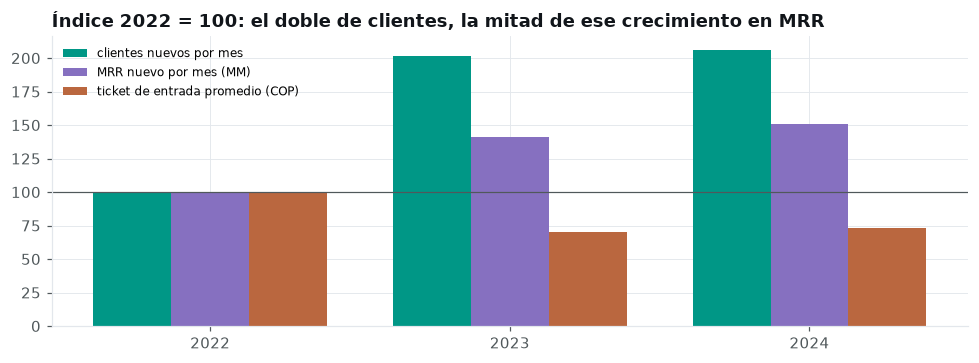

In [4]:
idx = por_anio[["clientes nuevos por mes", "MRR nuevo por mes (MM)", "ticket de entrada promedio (COP)"]]
idx = idx / idx.loc[2022] * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
xs = np.arange(len(idx))
for i, col in enumerate(idx.columns):
    ax.bar(xs + (i - 1) * 0.26, idx[col], width=0.26, color=VIZ[i], label=col)
ax.axhline(100, color=MUTED, lw=0.8); ax.set_xticks(xs); ax.set_xticklabels(idx.index)
ax.set_title("Índice 2022 = 100: el doble de clientes, la mitad de ese crecimiento en MRR"); ax.legend(fontsize=8); plt.tight_layout()

**Por qué tres medidas del ticket.** El primer pago puede traer un precio de bienvenida (notebook 03: 69 clientes
empiezan a la mitad). Por eso se mira también el MRR al 3.er mes, promedio y mediana. Las tres caen entre 25 % y 29 %: la conclusión
no depende de la medida.

## 2. Cómo cambió la mezcla de tamaños de entrada

tramo,≤ 25 mil,25–45 mil,45–65 mil,65–90 mil,90–130 mil,> 130 mil
year,,,,,,
2022,21.9,24.0,20.2,16.5,12.8,4.5
2023,33.2,32.0,18.6,8.6,5.8,1.7
2024,24.4,37.5,23.5,9.0,3.1,2.5


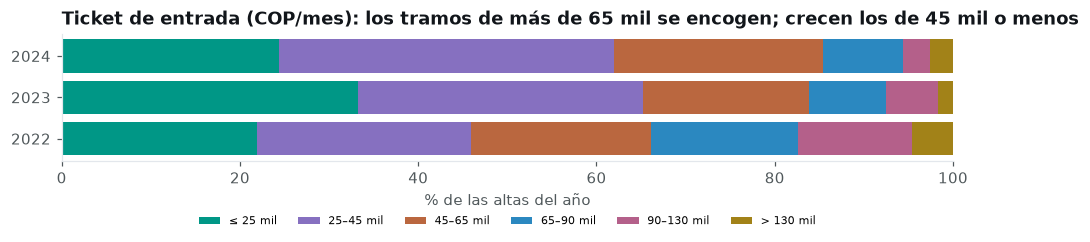

In [5]:
cortes = [0, 25_000, 45_000, 65_000, 90_000, 130_000, np.inf]
etiquetas = ["≤ 25 mil", "25–45 mil", "45–65 mil", "65–90 mil", "90–130 mil", "> 130 mil"]
altas["tramo"] = pd.cut(altas["delta"], cortes, labels=etiquetas)
mezcla = pd.crosstab(altas["year"], altas["tramo"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(9, 2.6))
izq = np.zeros(len(mezcla))
for i, col in enumerate(mezcla.columns):
    ax.barh(mezcla.index.astype(str), mezcla[col], left=izq, color=VIZ[i], label=col)
    izq += mezcla[col].to_numpy()
ax.set_xlim(0, 100); ax.set_xlabel("% de las altas del año"); ax.grid(False)
ax.set_title("Ticket de entrada (COP/mes): los tramos de más de 65 mil se encogen; crecen los de 45 mil o menos"); ax.legend(ncol=6, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
mezcla.round(1)

## 3. ¿Es la mezcla de industrias o pasa dentro de cada industria? Descomposición de Kitagawa

In [6]:
seg = altas.groupby(["year", "industry"]).agg(n=("customer_id", "nunique"), mrr=("delta", "sum"))
seg["ticket"] = seg["mrr"] / seg["n"]
share = seg["n"] / seg.groupby(level=0)["n"].transform("sum")
w0, w1, r0, r1 = share.loc[2022], share.loc[2024], seg["ticket"].loc[2022], seg["ticket"].loc[2024]
mix, rate = (w1 - w0) * (r0 + r1) / 2, (r1 - r0) * (w0 + w1) / 2
kit = pd.DataFrame({"participación 2022 %": w0 * 100, "participación 2024 %": w1 * 100, "ticket 2022": r0, "ticket 2024": r1,
                    "variación del ticket %": (r1 / r0 - 1) * 100, "efecto mezcla (COP)": mix, "efecto dentro de la industria (COP)": rate})
dentro = rate.sum() / (mix.sum() + rate.sum())
print(f"Δ ticket promedio 2022 → 2024: {mix.sum() + rate.sum():,.0f} COP = mezcla {mix.sum():,.0f} + dentro de cada industria {rate.sum():,.0f} ({dentro:.0%})")
kit.sort_values("efecto dentro de la industria (COP)").round(1)

Δ ticket promedio 2022 → 2024: -16,132 COP = mezcla -403 + dentro de cada industria -15,729 (97%)


,participación 2022 %,participación 2024 %,ticket 2022,ticket 2024,variación del ticket %,efecto mezcla (COP),efecto dentro de la industria (COP)
industry,,,,,,,
Retail,18.6,24.0,54680.5,30420.0,-44.4,2302.9,-5167.8
Restaurantes,27.7,27.6,66112.6,51767.7,-21.7,-40.4,-3966.6
Producción,26.0,20.4,52522.5,43573.7,-17.0,-2708.0,-2077.5
Tecnología,13.6,11.0,68863.2,52221.6,-24.2,-1589.6,-2050.8
Servicios profesionales,6.6,8.7,66576.6,45496.5,-31.7,1150.3,-1610.1
Salud,7.4,8.3,61075.0,50196.8,-17.8,481.4,-856.2


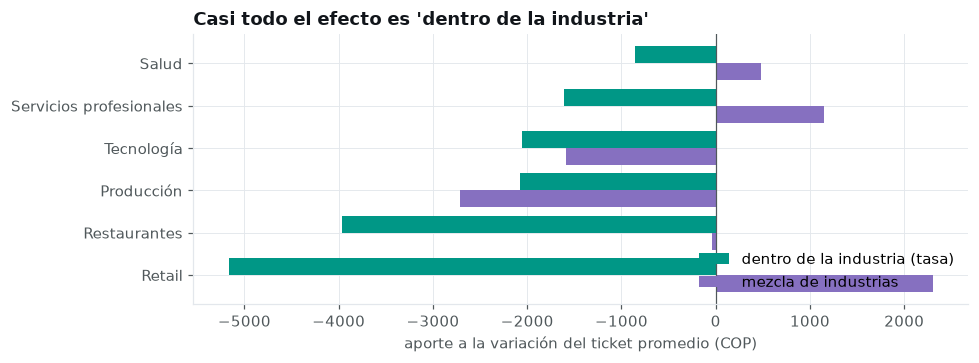

In [7]:
orden = kit.sort_values("efecto dentro de la industria (COP)").index
fig, ax = plt.subplots(figsize=(9, 3.4))
ys = np.arange(len(orden))
ax.barh(ys + 0.2, kit.loc[orden, "efecto dentro de la industria (COP)"], height=0.4, color=VIZ[0], label="dentro de la industria (tasa)")
ax.barh(ys - 0.2, kit.loc[orden, "efecto mezcla (COP)"], height=0.4, color=VIZ[1], label="mezcla de industrias")
ax.set_yticks(ys); ax.set_yticklabels(orden); ax.axvline(0, color=MUTED, lw=0.8)
ax.set_xlabel("aporte a la variación del ticket promedio (COP)"); ax.set_title("Casi todo el efecto es 'dentro de la industria'")
ax.legend(loc="lower right"); plt.tight_layout()

**Lectura.** Si el problema fuera que ahora entran industrias de ticket bajo, el efecto mezcla sería grande. Es pequeño: lo
que cae es el ticket **dentro** de cada industria, y en todas. Es consistente con la hipótesis de calidad o tamaño del lead, o con la de
más self-serve y planes baratos. **Sin canal, plan ni etapa del funnel no se puede distinguir**; por eso el Caso 1 propone medir
conversión por cohorte y camino (self-serve, directo a SQL, recorrido SDR) y descomponer mezcla frente a tasa por canal.

## 4. S&M frente a altas: no hay relación visible en el agregado

rezago 0 mes(es): correlación en niveles -0.58 | en diferencias +0.20
rezago 1 mes(es): correlación en niveles -0.58 | en diferencias -0.15
rezago 2 mes(es): correlación en niveles -0.47 | en diferencias -0.08
rezago 3 mes(es): correlación en niveles -0.31 | en diferencias +0.12


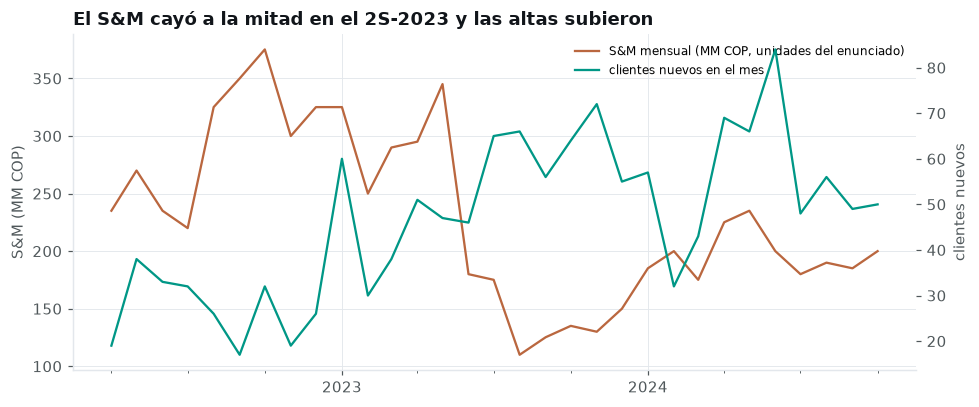

In [8]:
sm_m = sm.set_index("month")["sm_total_cop"]
nuevos_m = cm[cm["mv"] == "new"].groupby("month")["customer_id"].nunique()
j = pd.concat([sm_m.rename("sm"), nuevos_m.rename("nuevos")], axis=1).dropna()
j = j[j.index >= WINDOW]
for k in range(4):
    print(f"rezago {k} mes(es): correlación en niveles {j['sm'].shift(k).corr(j['nuevos']):+.2f} | en diferencias {j['sm'].diff().shift(k).corr(j['nuevos'].diff()):+.2f}")
corr_niv, corr_dif = j["sm"].corr(j["nuevos"]), j["sm"].diff().corr(j["nuevos"].diff())

fig, ax = plt.subplots()
x = j.index.to_timestamp()
ax.plot(x, j["sm"] / MM, color=VIZ[2], label="S&M mensual (MM COP, unidades del enunciado)"); ax.set_ylabel("S&M (MM COP)")
ax2 = ax.twinx(); ax2.plot(x, j["nuevos"], color=VIZ[0], label="clientes nuevos en el mes"); ax2.set_ylabel("clientes nuevos")
ax2.grid(False); ax2.spines["top"].set_visible(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
ax.set_title("El S&M cayó a la mitad en el 2S-2023 y las altas subieron"); eje_fechas(ax); plt.tight_layout()

In [9]:
q = sm.assign(q=sm["month"].dt.asfreq("Q")).groupby("q")["sm_total_cop"].sum()
nq = altas.assign(q=altas["month"].dt.asfreq("Q")).groupby("q").agg(nuevos=("customer_id", "nunique"), mrr_nuevo=("delta", "sum"))
cac = pd.DataFrame({"S&M (MM)": q / MM}).join(nq, how="inner")
cac["CAC combinado (MM por cliente)"] = cac["S&M (MM)"] / cac["nuevos"]
cac["payback sin margen (meses)"] = cac["CAC combinado (MM por cliente)"] * MM / (cac["mrr_nuevo"] / cac["nuevos"])
sm_2024 = sm_m[sm_m.index >= pd.Period("2024-01", "M")].mean()
print(f"S&M promedio 2024: {sm_2024 / MM:,.0f} MM al mes = {sm_2024 / m1:.1f} × el MRR de oct-2024 ({m1 / MM:.1f} MM)")
print(f"CAC combinado por trimestre: {cac['CAC combinado (MM por cliente)'].min():.1f} a {cac['CAC combinado (MM por cliente)'].max():.1f} MM | "
      f"payback sin margen: {cac['payback sin margen (meses)'].min():.0f} a {cac['payback sin margen (meses)'].max():.0f} meses")
print("(2022Q2 a 2024Q3 son trimestres completos; 2024Q4 solo tiene octubre)")
cac.drop(columns="mrr_nuevo").round(1)

S&M promedio 2024: 198 MM al mes = 2.1 × el MRR de oct-2024 (95.7 MM)
CAC combinado por trimestre: 2.2 a 13.0 MM | payback sin margen: 52 a 201 meses
(2022Q2 a 2024Q3 son trimestres completos; 2024Q4 solo tiene octubre)


,S&M (MM),nuevos,CAC combinado (MM por cliente),payback sin margen (meses)
q,,,,
2022Q2,740.2,90,8.2,154.9
2022Q3,895.1,75,11.9,183.7
2022Q4,1000.3,77,13.0,200.7
2023Q1,865.1,128,6.8,148.6
2023Q2,820.2,144,5.7,126.1
2023Q3,410.3,187,2.2,56.0
2023Q4,415.1,191,2.2,52.4
2024Q1,560.2,132,4.2,99.1
2024Q2,660.2,219,3.0,62.6


## 4b. Eficiencia del S&M: magic number y payback realizado por cohorte

Dos métricas estándar que Finora no tiene. **Magic number** = ARR nuevo del trimestre ÷ S&M del trimestre anterior (referencia de
mercado: 0,75; por debajo de 0,5 no se escala). **Payback realizado** = MRR acumulado de los clientes que entraron en un trimestre
÷ S&M de ese trimestre, con la retención real del modelo corregido y solo edades ya observadas.

magic number por trimestre: de 0.02 a 0.27 (referencia 0,75)
si las unidades del S&M fueran 10 veces menores: de 0.2 a 2.7

payback realizado a 24 meses (2 cohortes): 10% a 14% del S&M devuelto
cohortes que ya devolvieron su S&M: 0 de 10


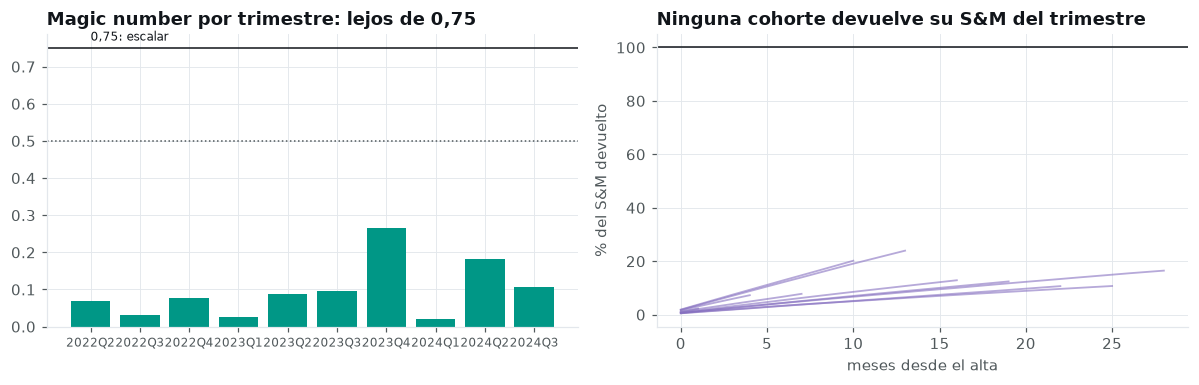

In [10]:
smq = sm.assign(q=sm["month"].dt.asfreq("Q")).groupby("q")
eff = pd.DataFrame({"S&M MM": smq["sm_total_cop"].sum() / MM, "meses": smq["month"].nunique()})
mrr_m = cm.groupby("month")["mrr_cop"].sum()
arr = mrr_m.groupby(mrr_m.index.asfreq("Q")).last() * 12
eff["ΔARR MM"] = (arr - arr.shift(1)) / MM
eff["magic number"] = eff["ΔARR MM"] / eff["S&M MM"].shift(1)
eff = eff[(eff["meses"] == 3) & (eff.index >= pd.Period("2022Q2", "Q"))]
print(f"magic number por trimestre: de {eff['magic number'].min():.2f} a {eff['magic number'].max():.2f} (referencia 0,75)")
print(f"si las unidades del S&M fueran 10 veces menores: de {eff['magic number'].min() * 10:.1f} a {eff['magic number'].max() * 10:.1f}")

coh = cm[cm["mv"] == "new"].assign(cohort=lambda d: d["month"].dt.asfreq("Q"))[["customer_id", "cohort"]]
c = cm.merge(coh, on="customer_id")
c = c[(c["age"] >= 0) & (c["cohort"] >= pd.Period("2022Q2", "Q"))]
pb = c.groupby(["cohort", "age"])["mrr_cop"].sum().groupby(level=0).cumsum().rename("acum").reset_index()
pb["recuperado"] = pb["acum"] / pb["cohort"].map(smq["sm_total_cop"].sum())
pb["madura"] = (cm["month"].max() - pb["cohort"].apply(lambda q: q.asfreq("M", "end"))).apply(lambda d: d.n) >= pb["age"]
pb = pb[pb["madura"]]
r24 = pb[pb["age"] == 24]
print(f"\npayback realizado a 24 meses ({len(r24)} cohortes): {r24['recuperado'].min():.0%} a {r24['recuperado'].max():.0%} del S&M devuelto")
print(f"cohortes que ya devolvieron su S&M: {int((pb.groupby('cohort')['recuperado'].max() >= 1).sum())} de {pb['cohort'].nunique()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar([str(q) for q in eff.index], eff["magic number"], color=VIZ[0])
ax[0].axhline(0.75, color=INK, lw=1); ax[0].text(0, 0.77, "0,75: escalar", fontsize=8, color=INK)
ax[0].axhline(0.5, color=MUTED, lw=1, ls=":"); ax[0].tick_params(axis="x", labelsize=8)
ax[0].set_title("Magic number por trimestre: lejos de 0,75")
for q, g in pb.groupby("cohort"):
    ax[1].plot(g["age"], g["recuperado"] * 100, color=VIZ[1], alpha=0.6, lw=1.2)
ax[1].axhline(100, color=INK, lw=1); ax[1].set_xlabel("meses desde el alta"); ax[1].set_ylabel("% del S&M devuelto")
ax[1].set_title("Ninguna cohorte devuelve su S&M del trimestre")
plt.tight_layout()

**Lectura.** O Finora gasta varias veces más de lo que un SaaS justifica, o el archivo de S&M tiene un error de unidad: con
unidades 10 veces menores, el magic number quedaría en rango normal. Las dos respuestas cambian decisiones, y por eso confirmar
las unidades con Finanzas es una decisión pendiente, no una nota al pie. Lo que no se hace: un modelo de rezagos (adstock) por
rubro, porque con 31 puntos y 7 rubros colineales sería ruido con aspecto de ciencia.

**Advertencias que acompañan cualquier cifra de S&M.**
- El S&M incluye nómina y equipo: no es solo adquisición.
- No hay atribución por canal ni separación entre self-serve y ventas, así que el CAC combinado no dice qué canal funciona.
- Las unidades vienen del enunciado. Con ellas, **el S&M duplica el MRR**; antes de cualquier decisión hay que confirmarlas con Finanzas.
- Tres lecturas posibles, ninguna demostrable con estos datos: el crecimiento es self-serve y no depende del S&M; el efecto tiene un
  rezago mayor a tres meses; el S&M de 2022 era ineficiente.

## 5. Foto por industria en oct-2024

In [11]:
ultimo = cm[(cm["month"] == cm["month"].max()) & (cm["mrr_cop"] > 0)]
gi = ultimo.groupby("industry").agg(clientes=("customer_id", "nunique"), mrr=("mrr_cop", "sum"))
gi["participación en el MRR %"] = gi["mrr"] / gi["mrr"].sum() * 100
gi["ARPA (COP)"] = gi["mrr"] / gi["clientes"]
gi["MRR (MM)"] = gi["mrr"] / MM
gi.drop(columns="mrr").sort_values("MRR (MM)", ascending=False).round(1)

,clientes,participación en el MRR %,ARPA (COP),MRR (MM)
industry,,,,
Restaurantes,478,33.5,67093.7,32.1
Producción,398,22.3,53620.3,21.3
Tecnología,211,15.1,68647.2,14.5
Retail,370,13.3,34527.3,12.8
Salud,128,9.0,67519.2,8.6
Servicios profesionales,144,6.7,44380.5,6.4


## Conclusión y lo que no se puede concluir

- **Hallazgo con datos reales:** se ganan más clientes, pero más pequeños, y pasa dentro de cada industria. Es el único trozo del funnel
  que estos datos permiten ver, y ya cambia la pregunta del CRO: de "¿por qué no cerramos más?" a "¿por qué lo que cerramos vale menos?".
- **No se puede concluir** ninguna hipótesis del funnel (demanda, calidad del lead, velocidad, post-SQL), la causalidad entre S&M y altas,
  ni la eficiencia por canal. Para eso el Caso 1 entrega el diseño de medición (eventos de etapa, tres caminos, conversión por cohorte,
  speed-to-lead, control estadístico) y un prototipo sintético rotulado como tal.

In [12]:
pct = lambda v: round(v * 100)
calculadas = {"crec_nuevos": pct(r("clientes nuevos por mes")), "crec_mrr_nuevo": pct(r("MRR nuevo por mes (MM)")),
              "caida_ticket": pct(-r("ticket de entrada promedio (COP)")), "caida_m3": pct(-r("MRR promedio al 3.er mes (COP)")),
              "caida_m3_med": pct(-r("MRR mediano al 3.er mes (COP)")), "kit_dentro": pct(dentro),
              "retail_caida": pct(-kit.loc["Retail", "variación del ticket %"] / 100),
              "corr_niveles": round(float(corr_niv), 2), "corr_dif": round(float(corr_dif), 2),
              "cac_min": round(float(cac["CAC combinado (MM por cliente)"].min()), 1), "cac_max": round(float(cac["CAC combinado (MM por cliente)"].max()), 1),
              "sm_vs_mrr": round(float(sm_2024 / m1), 1),
              "magic_min": round(float(eff["magic number"].min() * 100)), "magic_max": round(float(eff["magic number"].max() * 100)),
              "pb24_min": pct(r24["recuperado"].min()), "pb24_max": pct(r24["recuperado"].max())}
for k, v in calculadas.items():
    assert abs(KF[k] - v) < 0.011, (k, KF[k], v)
print("coinciden con key_figures.csv:", calculadas)

coinciden con key_figures.csv: {'crec_nuevos': 106, 'crec_mrr_nuevo': 51, 'caida_ticket': 27, 'caida_m3': 25, 'caida_m3_med': 29, 'kit_dentro': 97, 'retail_caida': 44, 'corr_niveles': -0.58, 'corr_dif': 0.2, 'cac_min': 2.2, 'cac_max': 13.0, 'sm_vs_mrr': 2.1, 'magic_min': 2, 'magic_max': 27, 'pb24_min': 10, 'pb24_max': 14}
